In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
torch.cuda.synchronize()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [ ]:
# TÍTULO: Entrenamiento del Modelo de Detección de Autos (YOLOv8)
# OBJETIVO: Entrenar una red neuronal convolucional utilizando Transfer Learning.

import torch
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
import cv2
import glob
import yaml
from datetime import datetime
import pandas as pd

# --- VERIFICACIÓN DE GPU (CRÍTICO PARA TU RTX 4070 Ti) ---
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    device_name = torch.cuda.get_device_name(0)
    print(f"Hardware detectado: {device_name}")
    print(f"   Memoria VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    device = 0 # ID de la GPU
else:
    print("No se detectó GPU. El entrenamiento será con CPU.")
    device = 'cpu'

# Configuración de Rutas
DATA_YAML = '../../datasets/01_autos/data.yaml'
PROJECT_DIR = '../../../../models/01_autos'

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/robertoplr/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch Version: 2.5.1+cu121
CUDA Available: True
Hardware detectado: NVIDIA GeForce RTX 4070 Ti
   Memoria VRAM: 12.45 GB


In [4]:
# Función para obtener el optimizador real cuando se usa 'auto'
def obtener_optimizador_real(modelo):
    """
    Recupera el nombre real del optimizador cuando la configuración es 'auto'.
    """
    try:
        # 1. Si el entrenamiento acaba de terminar y el objeto sigue en memoria RAM
        if hasattr(modelo, 'trainer') and modelo.trainer and hasattr(modelo.trainer, 'optimizer'):
            # El optimizador es un objeto (ej. <torch.optim.sgd.SGD object at 0x...>)
            # Obtenemos su nombre de clase real
            opt_obj = modelo.trainer.optimizer
            nombre_real = type(opt_obj).__name__
            
            # También podemos sacar el Learning Rate real final
            lr_final = opt_obj.param_groups[0]['lr']
            
            print(f"Decisión de 'Auto':")
            print(f"   • Optimizador:   {nombre_real}") # Dirá 'SGD' o 'AdamW'
            print(f"   • Learning Rate: {lr_final:.6f}")
            return

        # 2. Si el modelo fue cargado desde disco (.pt) y no hay trainer en memoria
        # Buscamos en los metadatos internos del archivo
        if hasattr(modelo, 'ckpt') and modelo.ckpt:
            train_args = modelo.ckpt.get('train_args', {})
            # A veces aquí también dice 'auto', en cuyo caso la única verdad está en los logs de texto
            print(f"Configuración guardada: {train_args.get('optimizer', 'Desconocido')}")
            print("Si aquí dice 'auto', por favor revisa el archivo '/runs/.../train/main.log'")

    except Exception as e:
        print(f"No se pudo recuperar automáticamente: {e}")


Entrenamiento 2026-08-07

In [5]:
# --- Resplit ---
# Ruta donde están los datos redistribuidos
RESPLIT_DATA_PATH = '../../datasets/01_autos/'

# Crear diccionario de configuración
yaml_resplit = {
    'path': RESPLIT_DATA_PATH, # Ruta Absoluta
    'train': 'train/images',    # Entrenamiento
    'val': 'val/images',        # Validación
    'test': 'test/images',      # Pruebas
    'names': { 0: 'car' }       # Clases
}

# Guardar el archivo data_resplit.yaml
yaml_path_resplit = os.path.join(RESPLIT_DATA_PATH , 'data_resplit.yaml')

with open(yaml_path_resplit, 'w') as f:
    yaml.dump(yaml_resplit, f)

print(f"Configuración Resplit creada en: {yaml_path_resplit}")

Configuración Resplit creada en: ../../datasets/01_autos/data_resplit.yaml


In [6]:
# --- Entrenando modelo YOLO11n con database Resplit y Transfer Learning  ---
print("Entrenando modelo YOLO11n con database Resplit y Transfer Learning...")

# Cargar modelo base
model_yolov11n_resplit_tl = YOLO('yolo11n.pt') 

# from datetime import datetime
# run_name = f"{datetime.now().strftime('%Y%m%d')}_v8n_resplit_dataset_tl"
run_name = f"100_v11n_resplit_dataset_tl"
# Entrenar
results_yolov11n_resplit_tl = model_yolov11n_resplit_tl.train(
    data=yaml_path_resplit,  # Apuntamos al YAML creado en la celda anterior
    project=PROJECT_DIR,      # ../../models/01_autos
    name=run_name,   # Nombre del experimento

    # Hiperparámetros Clave
    epochs=100,             # Máximo de pasadas (100)
    patience=20,            # Si no mejora en 20 épocas, parar (Early Stopping)
    batch=-1,               # AutoBatch (Usa el 90% de tu VRAM automáticamente)
    imgsz=640,              # Resolución de entrada estándar
    
    # Configuración de Hardware
    device=device,
    workers=6,              # Hilos de CPU para cargar datos

    # Gestión de Archivos    
    exist_ok=False,         # No sobrescribir si existe
    pretrained=True,        # Usar pesos de COCO (Con Transfer Learning)
    optimizer='auto',       # SGD o AdamW (Auto lo elige bien)
    verbose=True,
)

print("Finalizado")

Entrenando modelo YOLO11n con database Resplit y Transfer Learning...
Ultralytics 8.4.116 🚀 Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11873MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../datasets/01_autos/data_resplit.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train,

/home/robertoplr/miniconda3/envs/proyecto/lib/python3.10/site-packages/ultralytics/utils/tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:91.)
  sx = feats[0].new_full((w,), 1, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
/home/robertoplr/miniconda3/envs/proyecto/lib/python3.10/site-packages/ultralytics/utils/tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:91.)
  sy = feat

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1910.6±2060.1 MB/s, size: 75.1 KB)
train: Scanning /home/robertoplr/Documentos/moca_proyecto/datasets/01_autos/train/labels... 12913 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12913/12913 3.5Kit/s 3.7s0.0s
train: New cache created: /home/robertoplr/Documentos/moca_proyecto/datasets/01_autos/train/labels.cache
AutoBatch: Computing optimal batch size for imgsz=640 at 60.0% GPU memory utilization.
AutoBatch: CUDA:0 (NVIDIA GeForce RTX 4070 Ti) 11.59G total, 0.09G reserved, 0.06G allocated, 11.45G free
      Params      GFLOPs  GPU_mem (GB)  forward (ms) backward (ms)                   input                  output
     2590035       6.438         0.401         24.54           nan        (1, 3, 640, 640)                    list
     2590035       12.88         0.791         16.95           nan        (2, 3, 640, 640)                    list
     2590035       25.75         1.388         17.22           nan   

/home/robertoplr/miniconda3/envs/proyecto/lib/python3.10/site-packages/ultralytics/utils/tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:91.)
  sx = feats[0].new_full((w,), 1, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
/home/robertoplr/miniconda3/envs/proyecto/lib/python3.10/site-packages/ultralytics/utils/tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:91.)
  sy = feat

      1/100      2.94G     0.5498     0.8216      1.092         47        640: 100% ━━━━━━━━━━━━ 615/615 10.0it/s 1:010.1sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 9.8it/s 4.0s<0.1s
                   all       1614       1614      0.997      0.994      0.995       0.89

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      4.28G     0.5637     0.4189      1.083         66        640: 0% ──────────── 1/615 1.7it/s 0.2s<6:11

...

     93/100      4.28G     0.2723     0.1296     0.9242         19        640: 100% ━━━━━━━━━━━━ 615/615 12.7it/s 48.5s0.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 14.3it/s 2.7s0.1s
                   all       1614       1614      0.999          1      0.995      0.948

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/100      4.28G     0.3039     0.1307     0.9213         21        640: 0% ──────────── 1/615 1.8it/s 0.2s<5:47

/home/robertoplr/miniconda3/envs/proyecto/lib/python3.10/site-packages/ultralytics/utils/tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:91.)
  sx = feats[0].new_full((w,), 1, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
/home/robertoplr/miniconda3/envs/proyecto/lib/python3.10/site-packages/ultralytics/utils/tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:91.)
  sy = feat

     94/100      4.28G     0.2689     0.1273     0.9222         19        640: 100% ━━━━━━━━━━━━ 615/615 12.1it/s 50.8s0.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 14.0it/s 2.8s0.1s
                   all       1614       1614      0.999          1      0.995      0.948

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/100      4.28G     0.2742      0.125     0.9197         21        640: 0% ──────────── 1/615 1.7it/s 0.2s<5:55

/home/robertoplr/miniconda3/envs/proyecto/lib/python3.10/site-packages/ultralytics/utils/tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:91.)
  sx = feats[0].new_full((w,), 1, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
/home/robertoplr/miniconda3/envs/proyecto/lib/python3.10/site-packages/ultralytics/utils/tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:91.)
  sy = feat

     95/100      4.28G     0.2685     0.1265     0.9209         19        640: 100% ━━━━━━━━━━━━ 615/615 12.2it/s 50.4s0.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 13.7it/s 2.8s0.1s
                   all       1614       1614      0.999          1      0.995      0.948
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 75, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

95 epochs completed in 1.394 hours.
Optimizer stripped from /home/robertoplr/Documentos/moca_proyecto/notebooks/01_autos/models/01_autos/100_v11n_resplit_dataset_tl/weights/last.pt, 5.5MB
Optimizer stripped from /home/robertoplr/Documentos/moca_proyecto/notebooks/01_autos/models/01_autos/100_v11n_resplit_dataset_tl/weights/best.pt, 5.5MB

Validating /home/robertoplr/Docume

In [7]:
# --- RECUPERAR HIPERPARÁMETROS REALES ---
# Ejecutar al finalizar el entrenamiento
print(f"Batch Size: {model_yolov11n_resplit_tl.trainer.args.batch}") 
print(f"Optimizer: {obtener_optimizador_real(model_yolov11n_resplit_tl)}")
print(f"Learning Rate inicial: {model_yolov11n_resplit_tl.trainer.args.lr0}")

Batch Size: 21
Decisión de 'Auto':
   • Optimizador:   MuSGD
   • Learning Rate: 0.002082
Optimizer: None
Learning Rate inicial: 0.01


In [ ]:
print("Validando modelo 100_v11n_resplit_dataset_tl")

PROJECT_DIR = '../../../models/01_autos'
run_name = f"100_v11n_resplit_dataset_tl"

# Cargar el MEJOR modelo resultante del entrenamiento anterior
model_yolov11n_resplit_tl = os.path.join(PROJECT_DIR, run_name, 'weights', 'best.pt')
best_model = YOLO(model_yolov11n_resplit_tl)

# Ejecutar validación en split='test'
metrics = best_model.val(split='test', project=PROJECT_DIR, name=f"{run_name}_eval")

print(f"\nResultados Finales en Test del dataset Baseline:")
print(f"   mAP@50:    {metrics.box.map50:.4f} (Precisión holgada)")
print(f"   mAP@50-95: {metrics.box.map:.4f}  (Precisión estricta )")

Validando modelo 100_v11n_resplit_dataset_tl
Ultralytics 8.4.116 🚀 Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11873MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 268.5±69.2 MB/s, size: 77.5 KB)
val: Scanning /home/robertoplr/Documentos/moca_proyecto/datasets/01_autos/test/labels... 1615 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1615/1615 3.3Kit/s 0.5s0.1s
val: New cache created: /home/robertoplr/Documentos/moca_proyecto/datasets/01_autos/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 101/101 21.4it/s 4.7s0.0s
                   all       1615       1615      0.998          1      0.995      0.953
Speed: 0.4ms preprocess, 1.0ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /home/robertoplr/Documentos/moca_proyecto/notebooks/01_autos/models/01_autos/100_v11n_respl


image 1/1 /home/robertoplr/Documentos/moca_proyecto/notebooks/01_autos/../../datasets/01_autos/test/images/007341.jpg: 448x640 1 car, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)


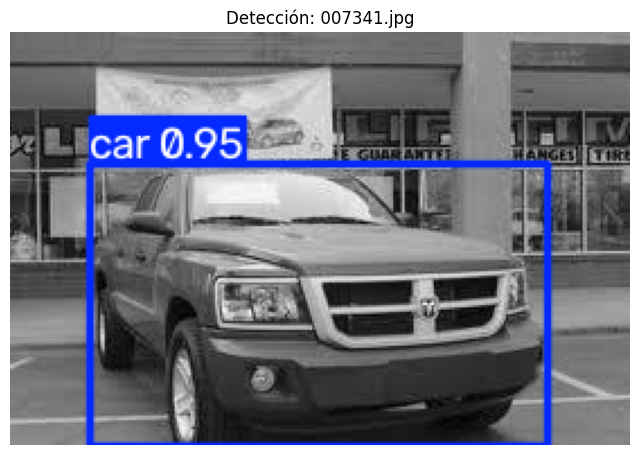


image 1/1 /home/robertoplr/Documentos/moca_proyecto/notebooks/01_autos/../../datasets/01_autos/test/images/006475.jpg: 448x640 1 car, 6.9ms
Speed: 1.1ms preprocess, 6.9ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)


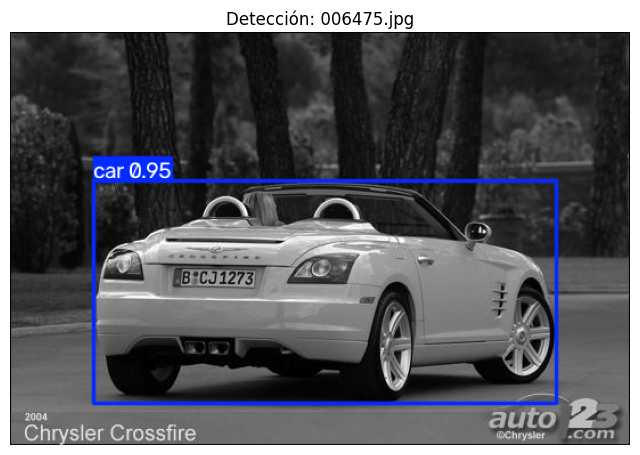


image 1/1 /home/robertoplr/Documentos/moca_proyecto/notebooks/01_autos/../../datasets/01_autos/test/images/009257.jpg: 480x640 1 car, 6.2ms
Speed: 1.0ms preprocess, 6.2ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)


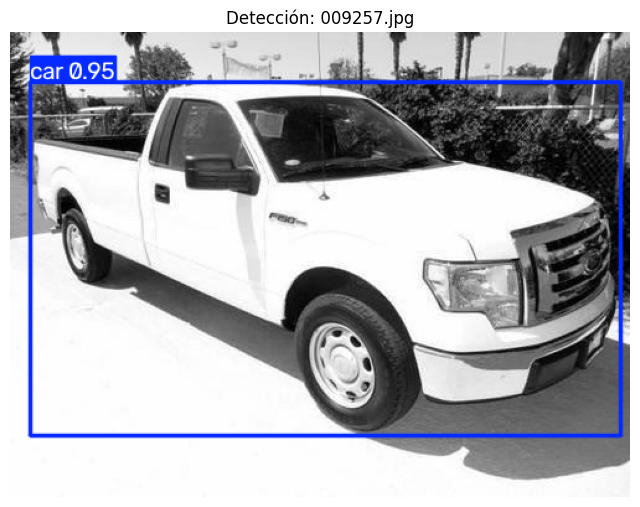


image 1/1 /home/robertoplr/Documentos/moca_proyecto/notebooks/01_autos/../../datasets/01_autos/test/images/011166.jpg: 480x640 1 car, 5.7ms
Speed: 0.9ms preprocess, 5.7ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)


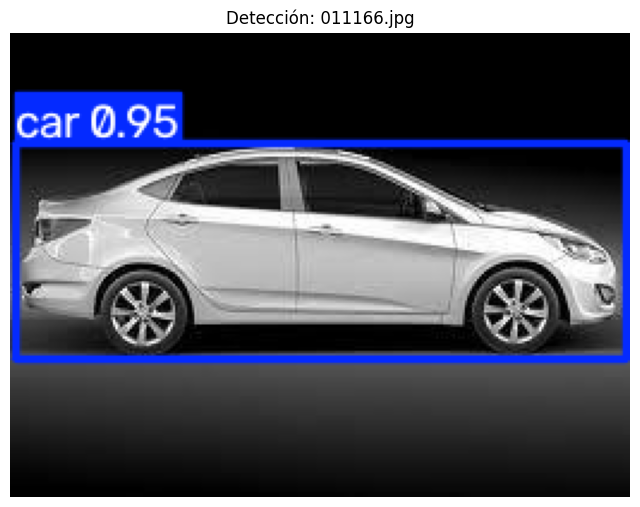

In [13]:
# Obtener imágenes del set de test para predecir
%matplotlib inline


# Cargar el MEJOR modelo resultante del entrenamiento anterior
run_name = "100_v11n_resplit_dataset_tl"
best_model_path = os.path.join(PROJECT_DIR, run_name, 'weights', 'best.pt')
best_model = YOLO(best_model_path)

test_images = glob.glob('../../datasets/01_autos/test/images/*.jpg')[:4] # Tomamos 4 ejemplos

for img_path in test_images:
    # Inferencia
    results = best_model.predict(img_path, conf=0.5)
    
    # Mostrar
    for r in results:
        im_array = r.plot()  # r.plot() dibuja las cajas en la imagen numpy
        plt.figure(figsize=(8,8))
        plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Detección: {os.path.basename(img_path)}")
        plt.show()

In [14]:
import shutil
import os

name = f"100_v11n_resplit_dataset_tl"
best_model_path = os.path.join(PROJECT_DIR, name, 'weights', 'best.pt')
best_model = YOLO(best_model_path)

PRODUCTION_PATH = '../../production_weights'
os.makedirs(PRODUCTION_PATH, exist_ok=True)

# Copiar y renombrar
target_path = os.path.join(PRODUCTION_PATH, '01_autos_best.pt')
shutil.copy(best_model_path, target_path)

print(f"Modelo exportado exitosamente a: {target_path}")
print("   Este archivo está listo para ser usado por el Pipeline de Placas.")

Modelo exportado exitosamente a: ../../production_weights/01_autos_best.pt
   Este archivo está listo para ser usado por el Pipeline de Placas.
